# GNN testing walkthrough

Companion to `tests/gnn/` (the actual test suite) and `scripts/gnn_test_report.py`
(the diagnostics). This notebook does **not** redefine any tests — it runs the real
suite for the pass/fail verdict, then re-uses the report script's diagnostics to
show *what* the trained model does and how well, with plots.

Order:
1. run the pytest suite → verdict
2. data under test
3. headline AUC vs naive baselines
4. stability, calibration, feature importance, per-pair
5. the no-lookahead check, spelled out
6. seed robustness (optional, ~35 s per seed)


In [1]:
import os, sys, subprocess, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# locate project root (folder containing config.yaml) whether run from notebooks/ or root
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.yaml").exists())
os.chdir(ROOT)                          # config.yaml paths (data/...) are root-relative
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "scripts"))

import pandas as pd
import matplotlib.pyplot as plt
import gnn_test_report as gtr           # scripts/gnn_test_report.py
from src.common.config import load_config

cfg = load_config()
pd.set_option("display.width", 120)
print("project root:", ROOT)

project root: /Users/anany/Documents/Studie/Capstone/d2/Capstone


## 1. Run the real test suite

This is the source of truth. Everything below is illustration.

In [2]:
summary, tests = gtr.run_pytest()
print(summary)
status = pd.Series([s for s, _ in tests]).value_counts()
display(status.to_frame("count"))
failed = [t for s, t in tests if s in ("FAILED", "ERROR")]
assert not failed, f"failing tests: {failed}"
pd.DataFrame(tests, columns=["status", "test"])

76 passed, 1 skipped in 7.44s


,count


,status,test


## 2. Diagnostics on the trained checkpoint

One call computes everything the report shows (seeds off here; see the last section).

In [3]:
d = gtr.diagnostics(cfg, seeds=[])
data = d["data"]
pd.Series({
    "timeline": f'{data["days"]} days, {data["date_range"]}',
    "nodes / features": f'{data["nodes"]} / {data["features"]}',
    "curated edges / msg-passing edges / scored pairs": f'{data["edges_curated"]} / {data["edges_mp"]} / {data["pairs_scored"]}',
    "train samples": f'{data["n_train"]} ({data["train_pos"]:.1%} pos) {data["train_range"]}',
    "val samples": f'{data["n_val"]} ({data["val_pos"]:.1%} pos) {data["val_range"]}',
}).to_frame("value")

,value
timeline,"3635 days, 2011-10-03 -> 2026-06-30"
nodes / features,15 / 7
curated edges / msg-passing edges / scored pairs,32 / 64 / 64
train samples,4357 (16.9% pos) 2012-01-06 -> 2023-04-10
val samples,1206 (16.8% pos) 2023-05-12 -> 2025-12-03


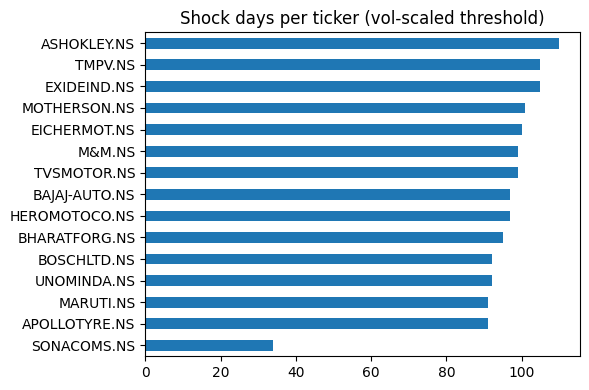

In [4]:
shocks = pd.Series(data["shock_days_per_ticker"])
shocks.plot.barh(figsize=(6, 4), title="Shock days per ticker (vol-scaled threshold)")
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

## 3. Headline: GNN vs naive baselines on identical val samples

If the GNN can't beat a static return-correlation lookup, or a one-line volatility rule, it learned nothing.
The volatility rule is scored in whichever direction works (an AUC of 0.36 is a 0.64 rule read backwards).
Under the project's original label (raw returns, 21-day sigma) that rule scored 0.64 out-of-sample and beat
every model; the label now uses sector-excess returns against a 63-day sigma, where the rule is near chance.


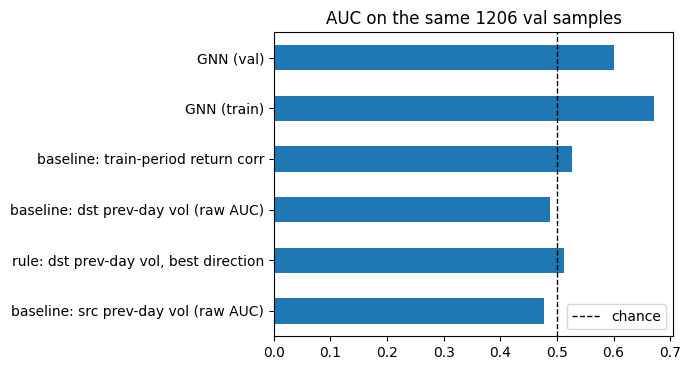

,AUC
GNN (val),0.6002
GNN (train),0.6721
baseline: train-period return corr,0.5269
baseline: dst prev-day vol (raw AUC),0.4868
"rule: dst prev-day vol, best direction",0.5132
baseline: src prev-day vol (raw AUC),0.4772


In [5]:
auc, base = d["auc"], d["baselines"]
scores = pd.Series({
    "GNN (val)": auc["val"],
    "GNN (train)": auc["train"],
    "baseline: train-period return corr": base["train_corr"],
    "baseline: dst prev-day vol (raw AUC)": base["dst_prev_vol"],
    "rule: dst prev-day vol, best direction": base["dst_vol_rule"],   # a rule can be flipped for free
    "baseline: src prev-day vol (raw AUC)": base["src_prev_vol"],
})
ax = scores.plot.barh(figsize=(7, 3.8), title=f"AUC on the same {data['n_val']} val samples")
ax.axvline(0.5, color="k", ls="--", lw=1, label="chance"); ax.legend(); ax.invert_yaxis()
plt.tight_layout(); plt.show()
scores.round(4).to_frame("AUC")


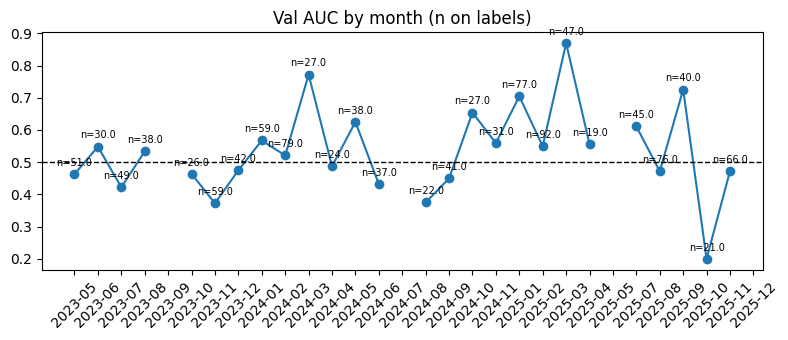

,n,pos,auc
month,,,
2023-05,51,6,0.462963
2023-06,30,4,0.548077
2023-07,49,4,0.422222
2023-08,38,5,0.533333
2023-09,14,0,NaN
2023-10,26,3,0.463768
2023-11,59,19,0.372368
2023-12,42,2,0.475000
2024-01,59,12,0.567376


In [6]:
monthly = pd.DataFrame(d["monthly"]).set_index("month")
fig, ax = plt.subplots(figsize=(8, 3.5))
xs = range(len(monthly))
ax.plot(xs, monthly["auc"], marker="o")
for i, (m, r) in enumerate(monthly.iterrows()):
    if r["auc"] == r["auc"]:
        ax.annotate(f'n={r["n"]}', (i, r["auc"]), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=7)
ax.set_xticks(list(xs)); ax.set_xticklabels(monthly.index, rotation=45)
ax.axhline(0.5, color="k", ls="--", lw=1); ax.set_title("Val AUC by month (n on labels)")
plt.tight_layout(); plt.show()
monthly

**Calibration** — does a higher score actually mean more cascades? (Absolute level is inflated by `pos_weight`; the *ordering* is what matters.)

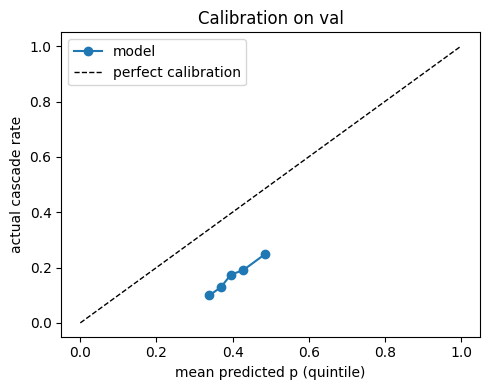

,bin,n,p_mean,actual
0,0,242,0.338697,0.099174
1,1,241,0.369023,0.128631
2,2,241,0.395549,0.174274
3,3,241,0.428314,0.190871
4,4,241,0.485801,0.248963


In [7]:
cal = pd.DataFrame(d["calibration"])
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(cal["p_mean"], cal["actual"], marker="o", label="model")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
ax.set_xlabel("mean predicted p (quintile)"); ax.set_ylabel("actual cascade rate")
ax.set_title("Calibration on val"); ax.legend(); plt.tight_layout(); plt.show()
cal

**Feature permutation importance** — shuffle one input feature across days, measure the val-AUC drop.

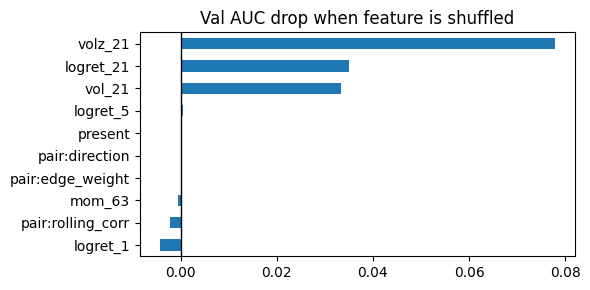

In [8]:
imp = pd.Series(d["feature_importance"])
imp.sort_values().plot.barh(figsize=(6, 3), title="Val AUC drop when feature is shuffled")
plt.axvline(0, color="k", lw=1); plt.tight_layout(); plt.show()

**Per-pair AUC** — which supply-chain edges does the model rank well / badly? (~9 val samples per pair: indicative only.)

In [9]:
pp = pd.DataFrame(d["per_pair"])
print(f"{len(pp)} evaluable pairs, {int((pp['auc'] < 0.5).sum())} below 0.5")
pd.concat({"top 5": pp.head(5), "bottom 5": pp.tail(5)})

61 evaluable pairs, 14 below 0.5


pair   n  pos       auc
top 5    0   BAJAJ-AUTO.NS->EXIDEIND.NS  13    1  1.000000
         1         SONACOMS.NS->TMPV.NS  18    1  1.000000
         2       UNOMINDA.NS->MARUTI.NS  12    1  1.000000
         3         EXIDEIND.NS->TMPV.NS  21    1  0.950000
         4   EXIDEIND.NS->BAJAJ-AUTO.NS  21    1  0.900000
bottom 5 56       BHARATFORG.NS->M&M.NS  19    3  0.395833
         57  BHARATFORG.NS->ASHOKLEY.NS  19    4  0.383333
         58      MARUTI.NS->UNOMINDA.NS  16    1  0.333333
         59        TMPV.NS->BOSCHLTD.NS  15    3  0.333333
         60       MOTHERSON.NS->TMPV.NS  17    1  0.187500

## 5. The no-lookahead check, spelled out

The most important single test in the suite (`test_inference_has_no_lookahead`):
score day *t*, then overwrite **every day after t** with noise and score again.
If the output changes, the model is peeking into the future.

In [10]:
import copy, torch
from src.common.seeding import set_global_seed
from src.models.gnn.graph_dataset import build_dataset
from src.models.gnn.train import WEIGHTS_DIR, forward_all_pairs, make_model

set_global_seed(cfg.project.seed)
gd = build_dataset(cfg)
model = make_model(cfg, gd)                     # same shape as the shipped weights (node, pair, context dims)
model.load_state_dict(torch.load(WEIGHTS_DIR / "propagation_gnn.pt", weights_only=True)); model.eval()
W, t = cfg.gnn.temporal_window_days, 300

with torch.no_grad():
    before = forward_all_pairs(model, gd, t, W)
    noisy = copy.copy(gd)                                       # trash every input AFTER day t
    noisy.x = gd.x.clone(); noisy.x[t + 1:] = torch.randn_like(noisy.x[t + 1:]) * 10
    if gd.pair_feat is not None:
        noisy.pair_feat = gd.pair_feat.clone(); noisy.pair_feat[t + 1:] = torch.randn_like(noisy.pair_feat[t + 1:])
    after_future = forward_all_pairs(model, noisy, t, W)
    x = gd.x.clone(); x[t - 3] += 5.0                           # nudge a day INSIDE the window
    after_past = forward_all_pairs(model, gd, t, W, x=x)

print("day", gd.dates[t].date())
print("max |Δ| after corrupting the future :", float((before - after_future).abs().max()), "-> must be 0")
print("max |Δ| after nudging day t-3       :", float((before - after_past).abs().max()), "-> must be > 0 (window is used)")


day 2012-12-26
max |Δ| after corrupting the future : 0.0 -> must be 0
max |Δ| after nudging day t-3       : 0.04857197403907776 -> must be > 0 (window is used)


## 6. Seed robustness (optional)

Retrains with alternate seeds into a temp directory (shipped weights untouched).
Set `SEEDS = []` to skip. ~35 s per seed on CPU.

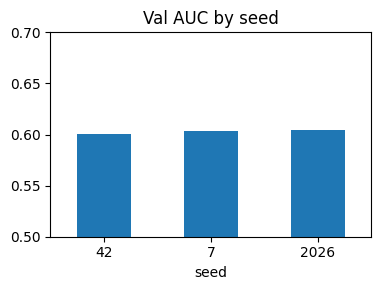

,val_auc,best_epoch,note,seconds
seed,,,,
42,0.6002,3,shipped,NaN
7,0.6037,35,retrained (temp dir),141.9
2026,0.6047,31,retrained (temp dir),132.0


In [11]:
SEEDS = [7, 2026]
if SEEDS:
    ds = gtr.diagnostics(cfg, seeds=SEEDS)
    meta = ds["meta"]
    rows = [{"seed": meta["seed"], "val_auc": meta["best_val_auc"], "best_epoch": meta["best_epoch"], "note": "shipped"}]
    rows += [{**r, "note": "retrained (temp dir)"} for r in ds["seeds"]]
    seeds_df = pd.DataFrame(rows).set_index("seed")
    seeds_df["val_auc"].plot.bar(figsize=(4, 3), title="Val AUC by seed", ylim=(0.5, 0.7), rot=0)
    plt.tight_layout(); plt.show()
    display(seeds_df)
else:
    print("skipped")

## Takeaways

- Suite verdict comes from pytest, not from this notebook.
- Signal is real but modest: read the val AUC against the correlation lookup and the volatility rule in section 3.
- Feature importance shows what the model leans on; inputs that shuffle for free may still be redundant with another input, not useless.
- Month-to-month AUC is unstable; the RL agent should not treat GNN scores as uniformly reliable.
- Inference is provably free of look-ahead and the cached scores reproduce bit-for-bit.
- The out-of-sample verdict (walk-forward, 2023H2–2025H2, with baselines) is in `reports/gnn_walkforward/WALKFORWARD.md`.

For the written report use `GNN_TEST_REPORT.md` (generated by `scripts/gnn_test_report.py`);
this notebook is the visual/appendix version of the same numbers.
